In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

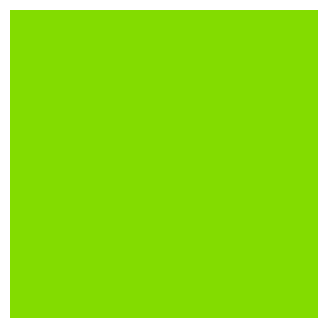

In [10]:
# Create a background that randomly samples a color from the Lab color space
lab_pixel = np.zeros((1, 1, 3), dtype=np.uint8)
lab_pixel[0,0] = [np.random.randint(255), np.random.randint(255), np.random.randint(255)]  # Example Lab color
# note: while LAB color space has L in [0, 100] and a,b in [-128, 127], OpenCV uses a scaled version where L is in [0, 255]
#  and a,b are in [0, 255]
lab_pixel[::,0]
rgb_pixel = cv2.cvtColor(lab_pixel, cv2.COLOR_LAB2RGB)

swatch = np.zeros((200, 200, 3), dtype=np.uint8)
swatch[:, :] = rgb_pixel[0, 0]

plt.figure(figsize=(4, 4))
plt.imshow(swatch)
plt.axis("off")
plt.show()

In [ ]:
lab_pixel[0,0] = [np.random.randint(100), np.random.randint(255), np.random.randint(255)]  # Example Lab color
lab_pixel[::,0]

array([[ 14,  75, 146]], dtype=uint8)

In [ ]:
# https://stackoverflow.com/questions/71865493/is-it-possible-to-create-a-random-shape-on-an-image-in-python
import cv2
import skimage.exposure
import numpy as np
from numpy.random import default_rng

# read input image
img = cv2.imread('lena.jpg')
height, width = img.shape[:2]

# define random seed to change the pattern
seedval = 75
rng = default_rng(seed=seedval)

# create random noise image
noise = rng.integers(0, 255, (height,width), np.uint8, True)

# blur the noise image to control the size
blur = cv2.GaussianBlur(noise, (0,0), sigmaX=15, sigmaY=15, borderType = cv2.BORDER_DEFAULT)

# stretch the blurred image to full dynamic range
stretch = skimage.exposure.rescale_intensity(blur, in_range='image', out_range=(0,255)).astype(np.uint8)

# threshold stretched image to control the size
thresh = cv2.threshold(stretch, 175, 255, cv2.THRESH_BINARY)[1]

# apply morphology open and close to smooth out and make 3 channels
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.merge([mask,mask,mask])

# add mask to input
result1 = cv2.add(img, mask)

# use canny edge detection on mask
edges = cv2.Canny(mask,50,255)

# thicken edges and make 3 channel
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
edges = cv2.morphologyEx(edges, cv2.MORPH_DILATE, kernel)
edges = cv2.merge([edges,edges,edges])

# merge edges with result1 (make black in result where edges are white)
result2 = result1.copy()
result2[np.where((edges == [255,255,255]).all(axis=2))] = [0,0,0]

# add noise to result where mask is white
noise = cv2.merge([noise,noise,noise])
result3 = result2.copy()
result3 = np.where(mask==(255,255,255), noise, result3)

# save result
cv2.imwrite('lena_random_blobs1.jpg', result1)
cv2.imwrite('lena_random_blobs2.jpg', result2)
cv2.imwrite('lena_random_blobs3.jpg', result3)

# show results
cv2.imshow('noise', noise)
cv2.imshow('blur', blur)
cv2.imshow('stretch', stretch)
cv2.imshow('thresh', thresh)
cv2.imshow('mask', mask)
cv2.imshow('edges', edges)
cv2.imshow('result1', result1)
cv2.imshow('result2', result2)
cv2.imshow('result3', result3)
cv2.waitKey(0)
cv2.destroyAllWindows()

- https://docs.opencv.org/3.4/df/d61/tutorial_random_generator_and_text.html
- https://docs.opencv.org/4.x/df/d9d/tutorial_py_colorspaces.html